# Batch single-FOV FLIM fitting
Fits every `.ptu` in a folder with a 3-exponential reconvolution model,  
exports one row per file to a CSV.

**Settings** — edit the config cell below, then `Run All`.

| Parameter | Value |
|-----------|-------|
| Exponentials | 3 |
| τ range | 0.145 – 45 ns |
| IRF | Machine IRF (peak-aligned to decay) |
| Optimizer | Differential evolution → LM polish |
| Output | `<PTU_FOLDER>/batch_fit_results.csv` |


In [49]:
from pathlib import Path

# ── Edit these ────────────────────────────────────────────────────────────────
PTU_FOLDER       = Path("/Volumes/Lexar/Layla/260217LMCR283TCAFADO40x.sptw/")
OUTPUT_CSV       = PTU_FOLDER / "batch_fit_results_cell_mask.csv"

# Fitting parameters
N_EXP            = 3
TAU_MIN_NS       = 0.145        # ns
TAU_MAX_NS       = 45.0         # ns

# Machine IRF — leave None to use FLIMKit default
MACHINE_IRF_PATH = None

# DE optimiser
DE_POPSIZE       = 15
DE_MAXITER       = 1000
WORKERS          = -1           # -1 = all cores

# ── Masking: choose one mode ───────────────────────────────────────────────────
#
#   'none'       — use all photons (default, fastest)
#   'threshold'  — exclude pixels below INTENSITY_THRESHOLD photons
#   'cell_mask'  — Otsu-based cell detection (excludes background)
#
MASK_MODE          = 'cell_mask'
INTENSITY_THRESHOLD = 2        # photons/pixel  (used when MASK_MODE='threshold')

# Minimum total photons per file to attempt fitting
MIN_PHOTONS        = 1_000


In [50]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from flimkit.PTU.reader      import PTUFile
from flimkit.FLIM.fitters    import fit_summed
from flimkit.configs         import (
    MACHINE_IRF_DEFAULT_PATH,
    MACHINE_IRF_FIT_BG, MACHINE_IRF_FIT_SIGMA, MACHINE_IRF_FIT_TAIL,
)
from flimkit.image.tools     import make_intensity_image, make_cell_mask, apply_intensity_threshold

# Resolve IRF
_irf_path = Path(MACHINE_IRF_PATH) if MACHINE_IRF_PATH else Path(MACHINE_IRF_DEFAULT_PATH)
if not _irf_path.exists():
    raise FileNotFoundError(f"Machine IRF not found: {_irf_path}")

_machine_irf_raw = np.load(str(_irf_path)).ravel().astype(float)
_machine_irf_raw = np.maximum(_machine_irf_raw, 0.0)
_machine_irf_raw /= _machine_irf_raw.sum()
PI_MACHINE = int(np.argmax(_machine_irf_raw))

print(f"Machine IRF : {_irf_path.name}  |  {len(_machine_irf_raw)} bins  |  peak bin {PI_MACHINE}")
print(f"FIT_BG={MACHINE_IRF_FIT_BG}  FIT_SIGMA={MACHINE_IRF_FIT_SIGMA}  HAS_TAIL={MACHINE_IRF_FIT_TAIL}")
print(f"n_exp={N_EXP}  τ=[{TAU_MIN_NS}, {TAU_MAX_NS}] ns")
print(f"Mask mode   : {MASK_MODE!r}" +
      (f"  threshold={INTENSITY_THRESHOLD} ph/px" if MASK_MODE=='threshold' else ""))

def get_irf(peak_bin: int, n_bins: int) -> np.ndarray:
    irf = _machine_irf_raw.copy()
    if irf.size > n_bins:
        irf = irf[:n_bins]
    elif irf.size < n_bins:
        irf = np.pad(irf, (0, n_bins - irf.size))
    shift = peak_bin - PI_MACHINE
    if shift:
        irf = np.roll(irf, shift)
    s = irf.sum()
    return irf / s if s > 0 else irf

def build_masked_decay(ptu: PTUFile) -> tuple[np.ndarray, int, str]:
    """
    Return (masked_decay, n_photons_used, mask_description).
    Applies MASK_MODE to restrict which pixels contribute to the summed decay.
    """
    if MASK_MODE == 'none':
        decay = ptu.summed_decay()
        return decay, int(decay.sum()), 'all pixels'

    # Both masking modes need the intensity image
    stack = ptu.raw_pixel_stack(channel=ptu.photon_channel)  # (Y, X, H)
    intensity = stack.sum(axis=-1)                            # (Y, X)

    if MASK_MODE == 'threshold':
        mask = intensity >= INTENSITY_THRESHOLD
        desc = f"threshold≥{INTENSITY_THRESHOLD}"

    elif MASK_MODE == 'cell_mask':
        mask = make_cell_mask(intensity)
        desc = f"cell_mask ({mask.sum()} px)"

    else:
        raise ValueError(f"Unknown MASK_MODE: {MASK_MODE!r}. "
                         "Choose 'none', 'threshold', or 'cell_mask'.")

    stack[~mask] = 0
    decay = stack.sum(axis=(0, 1))
    n_ph  = int(decay.sum())
    del stack
    return decay, n_ph, desc

print("\nImports OK ✓")


Machine IRF : machine_irf_default.npy  |  526 bins  |  peak bin 29
FIT_BG=True  FIT_SIGMA=False  HAS_TAIL=False
n_exp=3  τ=[0.145, 45.0] ns
Mask mode   : 'cell_mask'

Imports OK ✓


In [51]:
ptu_files = sorted(PTU_FOLDER.glob("*.ptu"))
print(f"Found {len(ptu_files)} .ptu files in {PTU_FOLDER}")
for p in ptu_files:
    print(f"  {p.name}")


Found 32 .ptu files in /Volumes/Lexar/Layla/260217LMCR283TCAFADO40x.sptw
  Ado_1.ptu
  Ado_2.ptu
  Ctrl_1.ptu
  Ctrl_2.ptu
  Dara_Ima_1.ptu
  Dara_Ima_2.ptu
  Dara_Ima_Ado_1.ptu
  Daratumab_1.ptu
  Daratumab_2.ptu
  Daratumab_Ado_1.ptu
  Daratumab_Ado_2.ptu
  Etr_Pom1_PSB_1.ptu
  Etr_Pom1_PSB_2.ptu
  Etr_Pom1_PSB_Ado_1.ptu
  Etr_Pom1_PSB_Ado_2.ptu
  Etrumadenant_1.ptu
  Etrumadenant_2.ptu
  Etrumadenant_Ado_1.ptu
  Etrumadenant_Ado_2.ptu
  Imaradenant_1.ptu
  Imaradenant_2.ptu
  Imaradenant_Ado_1.ptu
  Imaradenant_Ado_2.ptu
  PSB12379_1.ptu
  PSB12379_2.ptu
  PSB12379_Ado_1.ptu
  PSB12379_Ado_2.ptu
  Pom1_1.ptu
  Pom1_2.ptu
  Pom1_Ado_1.ptu
  Pom1_Ado_2.ptu
  Series001.ptu


In [52]:
from tqdm.notebook import tqdm

records = []
errors  = []

for ptu_path in tqdm(ptu_files, desc="Fitting"):
    row = {"file": ptu_path.name}
    try:
        ptu    = PTUFile(str(ptu_path), verbose=False)
        _      = ptu.summed_decay()                  # sets ptu.photon_channel
        n_bins = ptu.n_bins
        tcspc  = ptu.tcspc_res

        row["n_bins"]   = n_bins
        row["tcspc_ps"] = round(tcspc * 1e12, 4)

        decay, n_ph, mask_desc = build_masked_decay(ptu)
        row["n_photons"]  = n_ph
        row["mask_mode"]  = mask_desc
        row["peak_bin"]   = int(np.argmax(decay))

        if n_ph < MIN_PHOTONS:
            row["status"] = f"SKIPPED (<{MIN_PHOTONS} photons)"
            records.append(row)
            continue

        irf = get_irf(row["peak_bin"], n_bins)

        popt, s = fit_summed(
            decay, tcspc, n_bins, irf,
            has_tail      = MACHINE_IRF_FIT_TAIL,
            fit_bg        = MACHINE_IRF_FIT_BG,
            fit_sigma     = MACHINE_IRF_FIT_SIGMA,
            n_exp         = N_EXP,
            tau_min_ns    = TAU_MIN_NS,
            tau_max_ns    = TAU_MAX_NS,
            optimizer     = "de",
            de_popsize    = DE_POPSIZE,
            de_maxiter    = DE_MAXITER,
            workers       = WORKERS,
            polish        = True,
        )

        taus  = s["taus_ns"]
        amps  = s["amps"]
        fracs = s["fractions"]

        for k in range(N_EXP):
            row[f"tau{k+1}_ns"] = round(float(taus[k]),  5)
            row[f"amp{k+1}"]    = round(float(amps[k]),  4)
            row[f"frac{k+1}"]   = round(float(fracs[k]), 5)

        row["tau_mean_amp_ns"]   = round(s["tau_mean_amp_ns"],   5)
        row["tau_mean_int_ns"]   = round(s["tau_mean_int_ns"],   5)
        row["bg_fit"]            = round(float(s["bg_fit"]),     6)
        row["chi2_reduced"]      = round(s["reduced_chi2"],      5)
        row["chi2_reduced_tail"] = round(s["reduced_chi2_tail"], 5)
        row["chi2_full"]         = round(s["chi2"],              4)
        row["dof"]               = int(s["dof"])
        row["p_val"]             = round(s["p_val"],             6)
        row["irf_shift_bins"]    = round(float(s["irf_shift_bins"]), 4)
        row["irf_fwhm_eff_ns"]   = round(float(s["irf_fwhm_eff_ns"]), 4)
        row["fit_window_ns_lo"]  = round(s["fit_window_ns"][0], 4)
        row["fit_window_ns_hi"]  = round(s["fit_window_ns"][1], 4)
        row["optimizer_msg"]     = str(s["optimizer_msg"])[:80]
        row["status"]            = "OK"

    except Exception as e:
        row["status"] = f"ERROR: {e}"
        errors.append(ptu_path.name)
        import traceback; traceback.print_exc()

    records.append(row)

print(f"\n{sum(1 for r in records if r['status']=='OK')}/{len(ptu_files)} fitted successfully")
if errors:
    print(f"Errors: {errors}")


Fitting:   0%|          | 0/32 [00:00<?, ?it/s]

  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 30.000 cts/bin, upper bound = 60.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 23.500 cts/bin, upper bound = 47.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 28.000 cts/bin, upper bound = 56.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=15, maxiter=1000, workers=-1
  Running final LM polis

In [53]:
df = pd.DataFrame(records)

front_cols = ["file", "status", "mask_mode", "n_photons", "tcspc_ps", "n_bins", "peak_bin"]
tau_cols   = []
for k in range(N_EXP):
    tau_cols += [f"tau{k+1}_ns", f"amp{k+1}", f"frac{k+1}"]
mean_cols  = ["tau_mean_amp_ns", "tau_mean_int_ns"]
fit_cols   = ["bg_fit", "chi2_reduced", "chi2_reduced_tail", "chi2_full",
              "dof", "p_val", "irf_shift_bins", "irf_fwhm_eff_ns",
              "fit_window_ns_lo", "fit_window_ns_hi", "optimizer_msg"]

ordered   = [c for c in front_cols + tau_cols + mean_cols + fit_cols if c in df.columns]
remaining = [c for c in df.columns if c not in ordered]
df = df[ordered + remaining]

df.to_csv(OUTPUT_CSV, index=False)
print(f"CSV saved → {OUTPUT_CSV}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df[df.status == "OK"].head(10)


CSV saved → /Volumes/Lexar/Layla/260217LMCR283TCAFADO40x.sptw/batch_fit_results_cell_mask.csv
Shape: 32 rows × 29 columns



,file,status,mask_mode,n_photons,tcspc_ps,n_bins,peak_bin,tau1_ns,amp1,frac1,...,chi2_reduced,chi2_reduced_tail,chi2_full,dof,p_val,irf_shift_bins,irf_fwhm_eff_ns,fit_window_ns_lo,fit_window_ns_hi,optimizer_msg
0,Ado_1.ptu,OK,cell_mask (807935 px),314503,96.9697,528,29,4.97893,2785.0743,0.12659,...,2.63569,1.25579,1199.2390,455,0.0,-0.6585,0.097,0.097,44.9939,"DE success=True, fun=9.9321e+02; polished cost..."
1,Ado_2.ptu,OK,cell_mask (724858 px),258162,96.9697,528,29,4.71431,2734.0200,0.14095,...,2.75175,1.37329,1252.0441,455,0.0,-0.7018,0.097,0.097,44.9939,"DE success=True, fun=9.6343e+02; polished cost..."
2,Ctrl_1.ptu,OK,cell_mask (740596 px),345004,96.9697,527,29,4.87155,3017.0325,0.11526,...,3.58501,1.48838,1631.1816,455,0.0,-0.4843,0.097,0.097,44.9939,"DE success=True, fun=1.2361e+03; polished cost..."
3,Ctrl_2.ptu,OK,cell_mask (902561 px),368987,96.9697,528,29,4.68919,3358.4905,0.10339,...,5.45650,2.55588,2482.7073,455,0.0,-0.6295,0.097,0.097,44.9939,"DE success=True, fun=1.6685e+03; polished cost..."
4,Dara_Ima_1.ptu,OK,cell_mask (738290 px),233464,96.9697,527,29,4.99280,1949.7785,0.10365,...,2.67040,1.33210,1215.0327,455,0.0,-0.7584,0.097,0.097,44.9939,"DE success=True, fun=9.7114e+02; polished cost..."
5,Dara_Ima_2.ptu,OK,cell_mask (698154 px),267145,96.9697,527,29,4.92714,2232.1010,0.10529,...,2.58101,1.25241,1174.3598,455,0.0,-0.7239,0.097,0.097,44.9939,"DE success=True, fun=9.6097e+02; polished cost..."
6,Dara_Ima_Ado_1.ptu,OK,cell_mask (637006 px),307960,96.9697,525,29,4.93168,2561.1102,0.11607,...,3.07409,1.34967,1398.7101,455,0.0,-0.7210,0.097,0.097,44.9939,"DE success=True, fun=1.0505e+03; polished cost..."
7,Daratumab_1.ptu,OK,cell_mask (447649 px),205863,96.9697,527,29,5.01274,1634.1958,0.10270,...,2.58151,1.63337,1174.5852,455,0.0,-0.6821,0.097,0.097,44.9939,"DE success=True, fun=8.6302e+02; polished cost..."
8,Daratumab_2.ptu,OK,cell_mask (643813 px),237541,96.9697,528,29,5.04379,1926.9695,0.10262,...,2.45410,1.37844,1116.6163,455,0.0,-0.7464,0.097,0.097,44.9939,"DE success=True, fun=9.2209e+02; polished cost..."
9,Daratumab_Ado_1.ptu,OK,cell_mask (638445 px),272259,96.9697,527,29,5.10228,1972.9971,0.08574,...,2.61296,1.05373,1188.8972,455,0.0,-0.7009,0.097,0.097,44.9939,"DE success=True, fun=9.0537e+02; polished cost..."


── Summary statistics ───────────────────────────────────────
       tau1_ns  tau2_ns  tau3_ns  tau_mean_amp_ns  chi2_reduced_tail
count  32.0000  32.0000  32.0000          32.0000            32.0000
mean    4.9512   1.5180   0.2593           1.1247             1.4225
std     0.1646   0.0772   0.0219           0.0735             0.2706
min     4.3516   1.3512   0.2114           0.9569             1.0537
25%     4.9174   1.4823   0.2436           1.0857             1.2875
50%     4.9729   1.5278   0.2604           1.1284             1.3745
75%     5.0329   1.5835   0.2751           1.1821             1.4873
max     5.2411   1.6353   0.3190           1.2840             2.5559


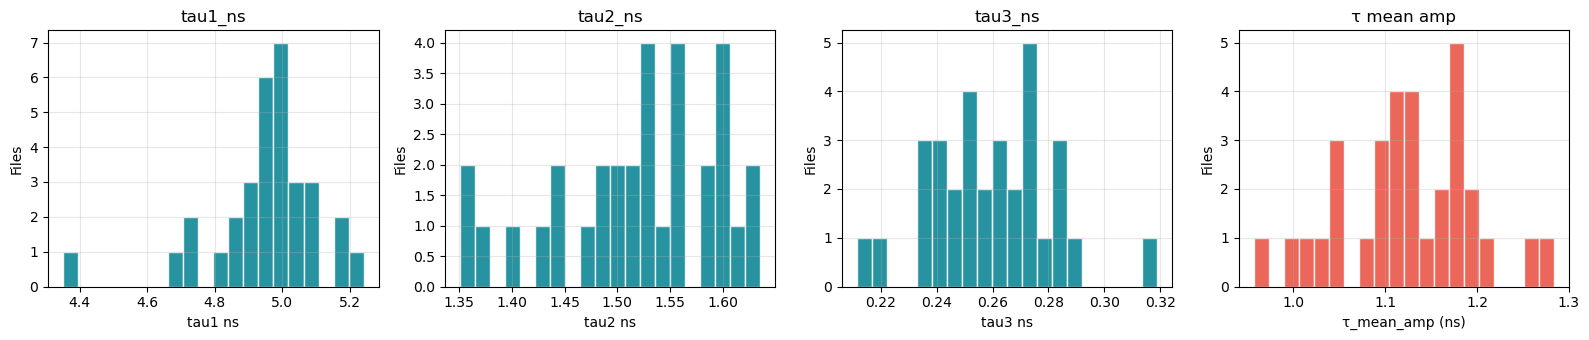


Plot saved → /Volumes/Lexar/Layla/260217LMCR283TCAFADO40x.sptw/batch_fit_tau_distributions.png


In [54]:
import matplotlib.pyplot as plt

ok = df[df.status == "OK"].copy()
if len(ok) == 0:
    print("No successful fits to plot.")
else:
    tau_keys = [f"tau{k+1}_ns" for k in range(N_EXP) if f"tau{k+1}_ns" in ok.columns]
    print("── Summary statistics ───────────────────────────────────────")
    cols_stat = tau_keys + ["tau_mean_amp_ns", "chi2_reduced_tail"]
    print(ok[cols_stat].describe().round(4).to_string())

    # Histogram of lifetimes
    fig, axes = plt.subplots(1, len(tau_keys) + 1, figsize=(4*(len(tau_keys)+1), 3.5))
    for ax, key in zip(axes, tau_keys):
        ax.hist(ok[key].dropna(), bins=20, color="#028090", edgecolor="white", alpha=0.85)
        ax.set_xlabel(key.replace("_", " "))
        ax.set_ylabel("Files")
        ax.set_title(key)
        ax.grid(True, alpha=0.3)

    axes[-1].hist(ok["tau_mean_amp_ns"].dropna(), bins=20,
                  color="#e74c3c", edgecolor="white", alpha=0.85)
    axes[-1].set_xlabel("τ_mean_amp (ns)")
    axes[-1].set_ylabel("Files")
    axes[-1].set_title("τ mean amp")
    axes[-1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(PTU_FOLDER / "batch_fit_tau_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved → {PTU_FOLDER / 'batch_fit_tau_distributions.png'}")
